# EMG Channel Reduction — Raw Signal Clustering (Deep Learning Pipeline)

Groups the 24 sEMG channels into **8 clusters** based on Pearson correlation of raw signals.

**Rationale:** Channels measuring the same underlying muscle group will have correlated
activation over time. Within a cluster the channels are interchangeable for the DL model —
keeping one representative per cluster reduces the electrode count from 24 to 8 while
preserving signal diversity.

**Pipeline:**
1. Load all subjects with `load_all_subjects` → `(N_reps, 1, 24, 1500)`
2. Pool every time point across all reps and subjects → `(N_total_samples, 24)`
3. Compute 24×24 Pearson correlation matrix
4. Agglomerative clustering (k=8, correlation distance, average linkage)
5. Select medoid per cluster (channel with highest mean correlation to cluster-mates)
6. Save `dl_representative_channels.npy` for use in `experiments/efficient/deep_learning/`

In [19]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# ── Path to shared src/ — clustering notebooks are at depth 2 from root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
SRC       = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from emg_loader import load_all_subjects

# ── Config
DATA_DIR      = '/Volumes/KRIS/data/UG_per_subject'
N_CH_CLUSTERS = 8
N_CHANNELS    = 24
GESTURE_NAMES = ['G1', 'G2', 'G3', 'G6', 'G7', 'G8', 'G9']

print('Imports OK.')

Imports OK.


In [20]:
subjects = load_all_subjects(DATA_DIR)
print(f'\nLoaded {len(subjects)} subjects')

Loading 44 subject file(s) from: /Volumes/KRIS/data/UG_per_subject

  → emg_gestures_03_U.mat  (280 samples)
  → emg_gestures_04_U.mat  (280 samples)
  → emg_gestures_05_U.mat  (280 samples)
  → emg_gestures_06_U.mat  (280 samples)
  → emg_gestures_07_U.mat  (280 samples)
  → emg_gestures_08_U.mat  (280 samples)
  → emg_gestures_09_U.mat  (280 samples)
  → emg_gestures_10_U.mat  (280 samples)
  → emg_gestures_11_U.mat  (280 samples)
  → emg_gestures_12_U.mat  (280 samples)
  → emg_gestures_13_U.mat  (280 samples)
  → emg_gestures_14_U.mat  (280 samples)
  → emg_gestures_15_U.mat  (280 samples)
  → emg_gestures_16_U.mat  (280 samples)
  → emg_gestures_17_U.mat  (280 samples)
  → emg_gestures_18_U.mat  (280 samples)
  → emg_gestures_19_U.mat  (280 samples)
  → emg_gestures_20_U.mat  (280 samples)
  → emg_gestures_22_U.mat  (280 samples)
  → emg_gestures_23_U.mat  (280 samples)
  → emg_gestures_24_U.mat  (280 samples)
  → emg_gestures_25_U.mat  (280 samples)
  → emg_gestures_26_U.mat  (28

KeyboardInterrupt: 

In [ ]:
# Pool every time point from every rep across all subjects → (N_total_samples, 24)
# X per subject: (N_reps, 1, 24, 1500)
# Each rep: X[i, 0, :, :] is (24, 1500) → transpose → (1500, 24)
all_signals = []
for _, X, _ in subjects:
    for i in range(X.shape[0]):
        all_signals.append(X[i, 0, :, :].T)   # (1500, 24)

pooled = np.concatenate(all_signals, axis=0)   # (N_total_samples, 24)
print(f'Pooled: {pooled.shape}  ({pooled.shape[0]:,} time points × {N_CHANNELS} channels)')

corr_matrix = np.corrcoef(pooled.T)            # (24, 24)
np.fill_diagonal(corr_matrix, 1.0)

mask = ~np.eye(N_CHANNELS, dtype=bool)
print(f'Off-diagonal corr  min={corr_matrix[mask].min():.3f}  '
      f'max={corr_matrix[mask].max():.3f}  '
      f'mean={corr_matrix[mask].mean():.3f}')

Pooled: (18480000, 24)  (18,480,000 time points × 24 channels)
Off-diagonal corr  min=0.558  max=0.948  mean=0.768


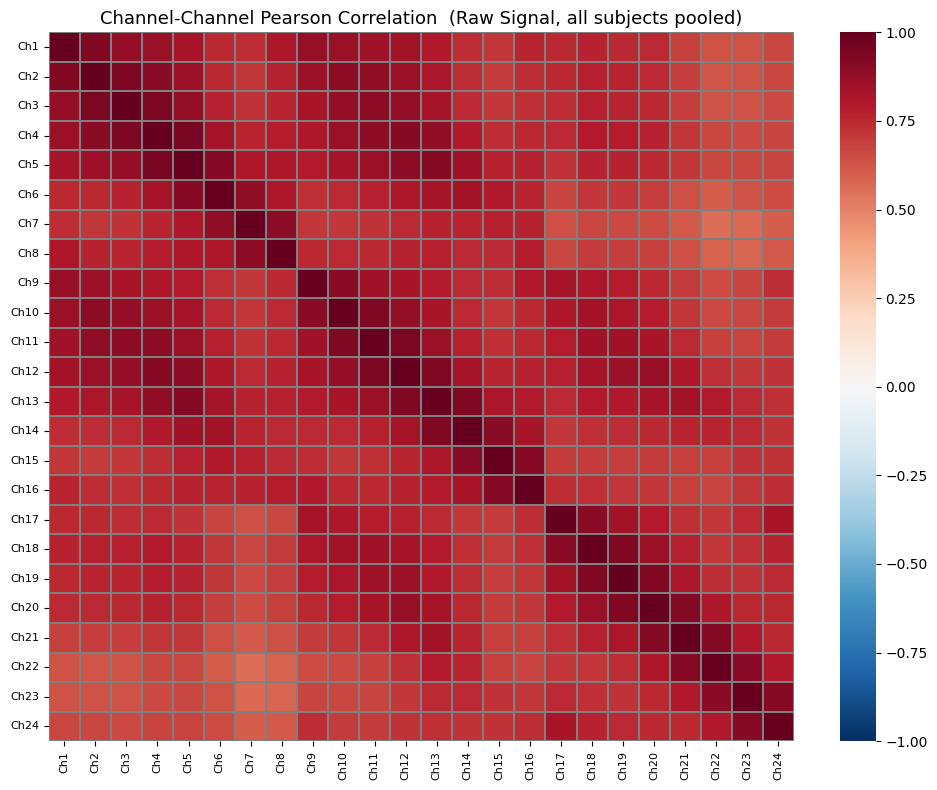

In [ ]:
ch_labels = [f'Ch{i+1}' for i in range(N_CHANNELS)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r',
            xticklabels=ch_labels, yticklabels=ch_labels,
            ax=ax, linewidths=0.3, linecolor='grey')
ax.set_title('Channel-Channel Pearson Correlation  (Raw Signal, all subjects pooled)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('dl_correlation_heatmap.png', dpi=150)
plt.show()

---
## Agglomerative Clustering

Distance = `1 − r` so identical channels have distance 0 and uncorrelated channels have distance 1.
Average linkage merges clusters based on the mean distance between all member pairs.

In [ ]:
dist_matrix = np.clip(1.0 - corr_matrix, 0.0, None)
dist_matrix = (dist_matrix + dist_matrix.T) / 2   # enforce exact symmetry
np.fill_diagonal(dist_matrix, 0.0)

condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

cluster_labels = fcluster(Z, N_CH_CLUSTERS, criterion='maxclust') - 1   # 0-indexed

print('Cluster composition:')
for c in range(N_CH_CLUSTERS):
    members = np.where(cluster_labels == c)[0]
    print(f'  Cluster {c}: channels {list(members + 1)}')

Cluster composition:
  Cluster 0: channels [23, 24]
  Cluster 1: channels [20, 21, 22]
  Cluster 2: channels [17, 18, 19]
  Cluster 3: channels [1, 2, 3, 4, 5, 10, 11, 12]
  Cluster 4: channels [9]
  Cluster 5: channels [6, 7, 8]
  Cluster 6: channels [13, 14]
  Cluster 7: channels [15, 16]


In [14]:
# Medoid = channel with highest mean Pearson r to all other cluster members
representative_channels = []

print(f'  {"Cluster":>7}  {"Members":>22}  Representative')
print('  ' + '-'*52)
for c in range(N_CH_CLUSTERS):
    members  = np.where(cluster_labels == c)[0]
    sub_corr = corr_matrix[np.ix_(members, members)]
    avg_corr = sub_corr.mean(axis=1)
    rep      = members[np.argmax(avg_corr)]
    representative_channels.append(rep)
    print(f'  {c:>7}  {str(list(members + 1)):>22}  Ch{rep + 1} (idx {rep})')

representative_channels = sorted(representative_channels)
print(f'\nFinal representatives (0-indexed): {representative_channels}')
print(f'Final representatives (1-indexed): {[c + 1 for c in representative_channels]}')

  Cluster                 Members  Representative
  ----------------------------------------------------
        0                [23, 24]  Ch23 (idx 22)
        1            [20, 21, 22]  Ch21 (idx 20)
        2            [17, 18, 19]  Ch18 (idx 17)
        3  [1, 2, 3, 4, 5, 10, 11, 12]  Ch4 (idx 3)
        4                     [9]  Ch9 (idx 8)
        5               [6, 7, 8]  Ch7 (idx 6)
        6                [13, 14]  Ch13 (idx 12)
        7                [15, 16]  Ch15 (idx 14)

Final representatives (0-indexed): [3, 6, 8, 12, 14, 17, 20, 22]
Final representatives (1-indexed): [4, 7, 9, 13, 15, 18, 21, 23]


In [15]:
def plot_dendrogram_with_cut(Z, k, n_channels=24, title='Channel Dendrogram',
                              save_path=None, representative_channels=None):
    """Draw dendrogram with a dashed cut line at height that yields exactly k clusters."""
    cut_height = Z[-(k - 1), 2]
    ch_labels  = [f'Ch{i+1}' for i in range(n_channels)]

    fig, ax = plt.subplots(figsize=(14, 5))
    dendrogram(Z, labels=ch_labels, color_threshold=cut_height,
               ax=ax, leaf_rotation=0, leaf_font_size=10)
    ax.axhline(cut_height, color='red', linestyle='--', linewidth=1.5,
               label=f'k={k} cut  (dist={cut_height:.4f})')
    ax.legend(fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Correlation distance  (1 − r)')

    if representative_channels:
        ylim   = ax.get_ylim()
        offset = (ylim[1] - ylim[0]) * 0.07
        for tick in ax.get_xticklabels():
            ch_idx = int(tick.get_text().replace('Ch', '')) - 1
            if ch_idx in representative_channels:
                ax.text(tick.get_position()[0], ylim[0] - offset, chr(9733),
                        ha='center', va='top', fontsize=13, color='red',
                        transform=ax.transData)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Cut height : {cut_height:.4f}  |  Clusters: {k}')

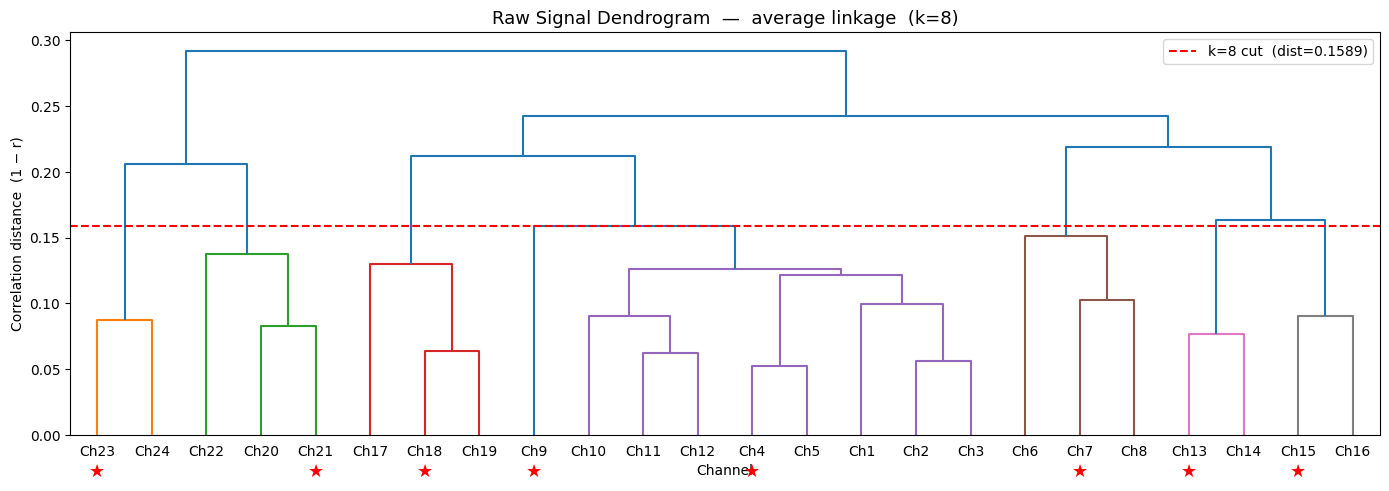

Cut height : 0.1589  |  Clusters: 8


In [16]:
plot_dendrogram_with_cut(
    Z, k=N_CH_CLUSTERS,
    title=f'Raw Signal Dendrogram  —  average linkage  (k={N_CH_CLUSTERS})',
    save_path='dl_channel_dendrogram.png',
    representative_channels=representative_channels,
)

  k= 2  silhouette=0.3098
  k= 3  silhouette=0.2878
  k= 4  silhouette=0.3023
  k= 5  silhouette=0.3372
  k= 6  silhouette=0.3639
  k= 7  silhouette=0.3458
  k= 8  silhouette=0.2822
  k= 9  silhouette=0.2562
  k=10  silhouette=0.2169
  k=11  silhouette=0.2050
  k=12  silhouette=0.2156


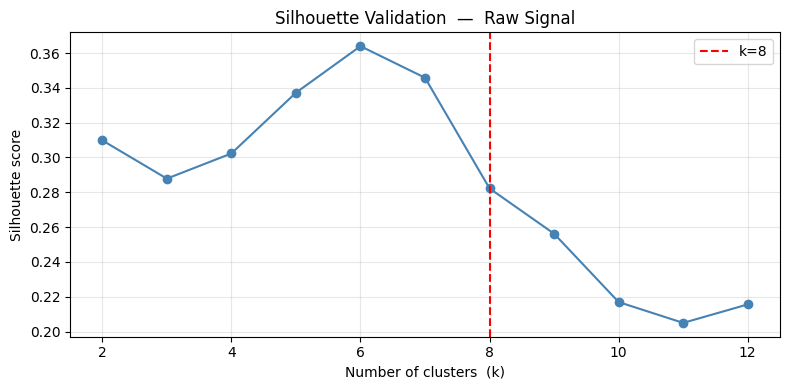

In [17]:
# Silhouette score: +1 = well-separated, 0 = overlapping, -1 = wrong cluster
# Sweep k=2..12 to check whether k=8 sits near a local maximum
k_range    = range(2, 13)
sil_scores = []

for k in k_range:
    labels_k = fcluster(Z, k, criterion='maxclust') - 1
    score    = silhouette_score(dist_matrix, labels_k, metric='precomputed')
    sil_scores.append(score)
    print(f'  k={k:>2}  silhouette={score:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), sil_scores, marker='o', color='steelblue', linewidth=1.5)
ax.axvline(N_CH_CLUSTERS, color='red', linestyle='--', label=f'k={N_CH_CLUSTERS}')
ax.set_xlabel('Number of clusters  (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Validation  —  Raw Signal')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dl_silhouette.png', dpi=150)
plt.show()

In [18]:
np.save('dl_representative_channels.npy', np.array(representative_channels))
np.save('dl_cluster_labels.npy', cluster_labels)
print('Saved: dl_representative_channels.npy,  dl_cluster_labels.npy')
print(f'Selected channels (1-indexed): {[c + 1 for c in representative_channels]}')
print()
print('To use in the efficient model notebook:')
print('  channels = np.load("experiments/clustering/dl_representative_channels.npy")')
print('  X_reduced = X[:, :, channels, :]   # (N, 1, 8, 1500)')

Saved: dl_representative_channels.npy,  dl_cluster_labels.npy
Selected channels (1-indexed): [4, 7, 9, 13, 15, 18, 21, 23]

To use in the efficient model notebook:
  channels = np.load("experiments/clustering/dl_representative_channels.npy")
  X_reduced = X[:, :, channels, :]   # (N, 1, 8, 1500)
